# Building a Network

A whole-brain model is many neural-mass nodes wired together by a **connectome**: a
structural-connectivity matrix of coupling weights, and (optionally) inter-region distances
that become conduction **delays**. In this tutorial you will build one with the high-level
{class}`~brainmass.Network` class and a bundled example connectome. You will:

1. load a connectome from {mod}`brainmass.datasets` (no download required),
2. wire its weights and distances into a delay-coupled {class}`~brainmass.Network`,
3. drive the whole network with the {class}`~brainmass.Simulator`, and
4. visualise the connectivity and the multi-region activity, and compute functional
   connectivity.

:::{important}
A delay-coupled `Network` sizes its delay buffer from the global `dt` at **construction**
time, so set `brainstate.environ.set(dt=...)` *before* you build it (we do this in the import
cell below).
:::

In [1]:
import brainmass
import brainstate
import brainunit as u
import numpy as np
import matplotlib.pyplot as plt

# Set dt BEFORE building a delay-coupled Network (its delay buffer is sized now).
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## 1. Load a connectome

{mod}`brainmass.datasets` ships small, license-clean example data so every notebook runs with
**no external download**. `load_dataset('example_connectome')` returns a typed
{class}`~brainmass.datasets.Connectome` with three fields:

- `weights` — an `(N, N)` structural-connectivity matrix (symmetric, zero diagonal),
- `distances` — an `(N, N)` matrix of inter-region distances, **unit-aware** (in `u.mm`),
- `labels` — the region names.

This bundled connectome has `N = 8` regions — small enough to simulate instantly and to read
off the connectivity matrix by eye.

In [2]:
conn = brainmass.datasets.load_dataset("example_connectome")
N = conn.weights.shape[0]

print("regions:", list(conn.labels))
print("weights shape:", conn.weights.shape)
print("distances unit:", u.get_unit(conn.distances), "| max distance:", conn.distances.max())
print("zero diagonal:", bool(np.allclose(np.diag(conn.weights), 0)),
      "| symmetric:", bool(np.allclose(conn.weights, conn.weights.T)))

regions: [np.str_('R0'), np.str_('R1'), np.str_('R2'), np.str_('R3'), np.str_('R4'), np.str_('R5'), np.str_('R6'), np.str_('R7')]
weights shape: (8, 8)
distances unit: mm | max distance: 80. mm
zero diagonal: True | symmetric: True


Let us look at the connectivity matrix. {func}`brainmass.viz.plot_connectivity` draws any
square matrix as a labelled heatmap — the weights on the left, the distances on the right.

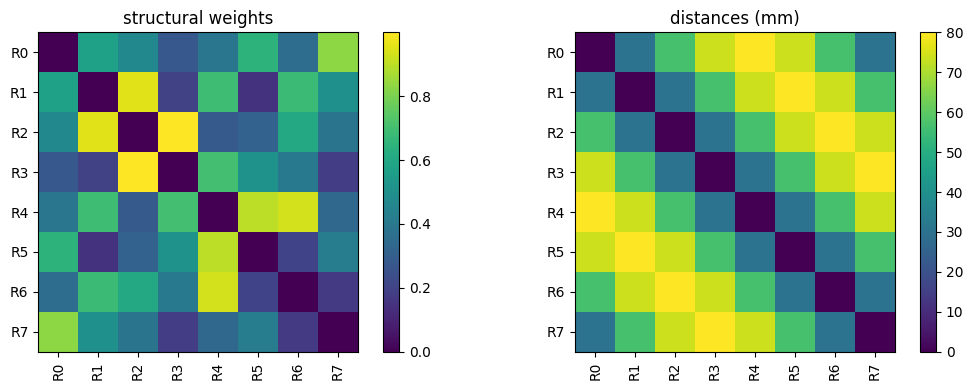

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
brainmass.viz.plot_connectivity(conn.weights, labels=list(conn.labels), ax=ax1)
ax1.set_title("structural weights")
brainmass.viz.plot_connectivity(conn.distances, labels=list(conn.labels), ax=ax2)
ax2.set_title("distances (mm)")
fig.tight_layout()

## 2. Wire it into a `Network`

{class}`~brainmass.Network` encapsulates the whole-brain wiring that the examples used to
copy-paste: it zeros the connectivity diagonal, turns `distance / speed` into conduction
delays, prefetches each region's *delayed* state, and feeds a
{class}`~brainmass.DiffusiveCoupling` current back into the node.

We give it a bank of `N` {class}`~brainmass.HopfStep` oscillators (one per region), the
structural `weights`, the `distances` together with a conduction `speed` (so
`delay = distance / speed`), and tell it which node state variable to couple (`x`) and how
strongly (`k`).

In [4]:
nodes = brainmass.HopfStep(in_size=N, a=0.2, w=0.3)

net = brainmass.Network(
    nodes,
    conn=conn.weights,
    distance=conn.distances,
    speed=10.0 * u.mm / u.ms,      # conduction speed -> delays = distance / speed
    coupling="diffusive",          # k * sum_j W_ij (x_j(delayed) - x_i)
    coupled_var="x",
    k=0.5,                          # global coupling strength
)

print("network of", net.n_node, "regions, coupling:", type(net.coupling).__name__)

network of 8 regions, coupling: DiffusiveCoupling


## 3. Drive it with the `Simulator`

The `Simulator` drives a `Network` exactly as it drove a single node — it does not care how
many regions there are. We record the coupled state of every region each step with a callable
monitor (`lambda m: m.node.x.value`), discarding a short transient.

activity shape (steps, regions): (2500, 8)


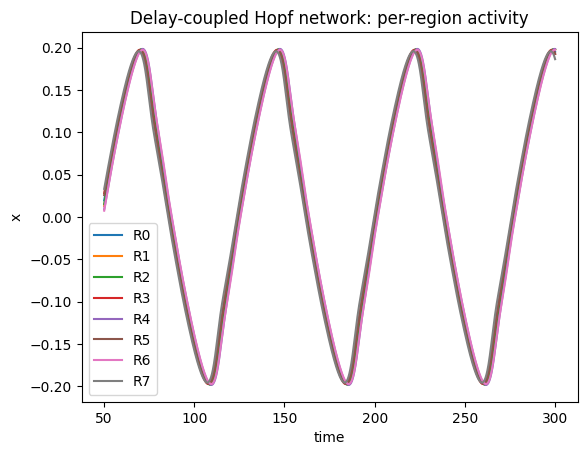

In [5]:
sim = brainmass.Simulator(net, dt=0.1 * u.ms)
res = sim.run(
    300.0 * u.ms,
    monitors=lambda m: m.node.x.value,   # (steps, regions)
    transient=50.0 * u.ms,
)
activity = res["output"]
print("activity shape (steps, regions):", activity.shape)

ax = brainmass.viz.plot_timeseries(activity, ts=res["ts"], labels=list(conn.labels))
ax.set_title("Delay-coupled Hopf network: per-region activity")
ax.set_ylabel("x");

## 4. Functional connectivity

The *structural* connectivity is how the regions are wired; the **functional** connectivity
(FC) is how correlated their activity turns out to be. {func}`brainmass.viz.plot_functional_connectivity`
computes the FC matrix from a `(time, region)` trajectory (via
{func}`braintools.metric.functional_connectivity`) and plots it. Coupling makes the regions
co-vary, so the FC reflects the structure that produced it.

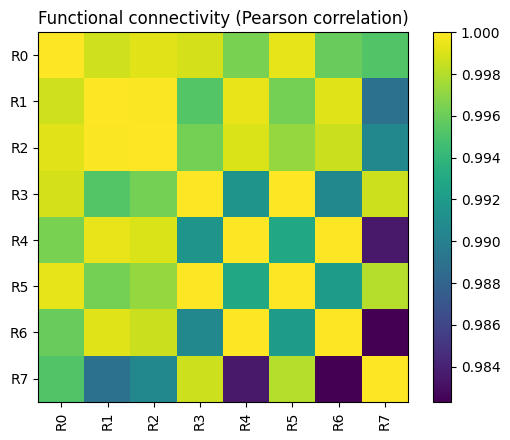

In [6]:
ax = brainmass.viz.plot_functional_connectivity(
    np.asarray(activity), labels=list(conn.labels)
)
ax.set_title("Functional connectivity (Pearson correlation)");

## Adding noise and other node models

Everything you learned in the previous tutorials composes here. The node can be any model,
and it can carry its own noise — a {class}`~brainmass.WilsonCowanStep` bank with an
{class}`~brainmass.OUProcess` on its excitatory population gives a noisy resting-state network
in a few lines. We couple the `rE` variable this time.

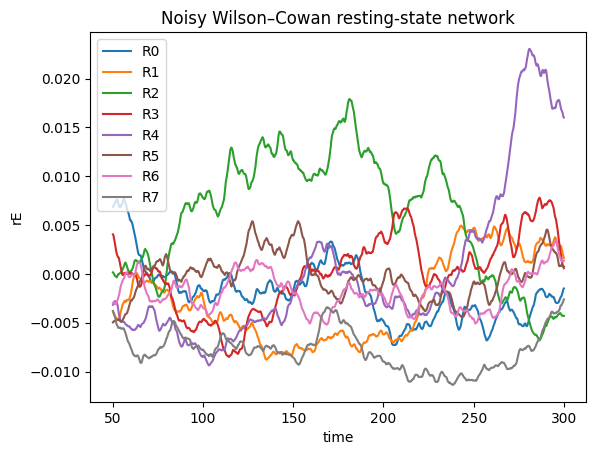

In [7]:
brainstate.random.seed(0)
wc_nodes = brainmass.WilsonCowanStep(
    in_size=N,
    noise_E=brainmass.OUProcess(in_size=N, sigma=0.1, tau=50.0 * u.ms),
)
wc_net = brainmass.Network(
    wc_nodes,
    conn=conn.weights,
    distance=conn.distances,
    speed=10.0 * u.mm / u.ms,
    coupled_var="rE",
    k=0.1,
)
res_wc = brainmass.Simulator(wc_net, dt=0.1 * u.ms).run(
    300.0 * u.ms, monitors=lambda m: m.node.rE.value, transient=50.0 * u.ms
)
ax = brainmass.viz.plot_timeseries(res_wc["output"], ts=res_wc["ts"], labels=list(conn.labels))
ax.set_title("Noisy Wilson–Cowan resting-state network")
ax.set_ylabel("rE");

## What you learned

- {mod}`brainmass.datasets` provides a bundled `example_connectome` (weights + mm distances +
  labels) so networks are runnable with no download.
- {class}`~brainmass.Network` wires a node bank into a delay-coupled whole-brain model:
  `conn` (weights), `distance` + `speed` (→ delays), `coupled_var`, and `k`.
- The {class}`~brainmass.Simulator` drives a network exactly like a single node.
- {mod}`brainmass.viz` plots the connectivity, the per-region activity, and the functional
  connectivity.
- Any node model and any noise process composes inside a `Network`.

:::{tip}
`Network` is the high-level builder. If you need a *custom* coupling rule — to wire the
delayed-state prefetch and coupling kernel by hand — see {doc}`/howto/custom_coupling`.
:::

## Next steps

- {doc}`/tutorials/05_forward_models` — map network activity to BOLD / EEG / MEG signals.
- {doc}`/tutorials/06_fitting_with_gradients` — fit network parameters to data with gradients.
- {doc}`/howto/custom_coupling` — build a bespoke coupling by hand.